In [10]:
# MÓDULOS E IMPORTAÇÕES
import kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns       # Referência de estudo: https://www.dannidanliu.com/introduction-to-s/

from datetime import date, datetime

In [11]:
# Loading data
file = 'air traffic.csv'
df_original = pd.read_csv(f'data\{file}')

In [12]:
# Processing data
df = df_original.copy()

df = df[['Year', 'Month', 'Flt']]
df['date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))
df['flights'] = df['Flt'].str.replace(',', '').astype('Int32')

df = df.drop(columns=['Year', 'Month', 'Flt'])
df = df.sort_values('date')

# Linear Regression Models

In [13]:
def process_historical_data(df, K):

    X = pd.DataFrame()
    
    for i in range(1, K + 1):
        v = df['flights'].rename(f'x_{i}').shift(i)
        X = pd.concat([X, v], axis=1)

    y = df.copy()
    y.rename(columns={'flights': 'y'}, inplace=True)

    df_processed = pd.concat([y, X], axis=1).dropna().reset_index(drop=True)  # for dropping redundant rows with null values

    return df_processed

In [14]:
df_validation_metrics = pd.DataFrame()
K = 5 # Optimal value

df_processed = process_historical_data(df, K)

# Solicitação do item c)
df_train = df_processed[df_processed['date'] <= '2019-12-01']
df_valid = df_processed[('2019-12-01' < df_processed['date']) & (df_processed['date'] <= '2021-12-01')]
df_test = df_processed['2021-12-01' < df_processed['date']]

# GAMBIARRA RÁPIDA
df_train = pd.concat([df_train, df_valid])
df_valid = df_test

X_train = df_train.drop(columns=['date','y'])
y_train = df_train['y']

X_valid = df_valid.drop(columns=['date','y'])
y_valid = df_valid['y']

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = pd.Series(model.predict(X_valid))

df_result = pd.concat(
[y_valid.rename('y').reset_index(drop=True), 
    y_pred.rename('ŷ = f(x,θ)').astype(int).reset_index(drop=True)],  # deliberadamente converti a previsão para um número inteiro. 
axis = 1
)

df_result.insert(0, 'date', df_valid['date'].reset_index(drop=True))

df_result['ϵ = y - ŷ'] = df_result['y'] - df_result['ŷ = f(x,θ)']
df_result['|ϵ|'] = abs(df_result['ϵ = y - ŷ'])
df_result['ϵ²'] = df_result['ϵ = y - ŷ']*df_result['ϵ = y - ŷ']
df_result['ϵr = 1 - ŷ/y'] = df_result['ϵ = y - ŷ']/df_result['y']
df_result['|er|'] = abs(df_result['ϵr = 1 - ŷ/y'])
df_result['100% × |er|'] = df_result['|er|'].map('{:.2%}'.format)

# display(df_result.head())
# display(df_result.drop(columns='date').describe())

MSE = df_result['ϵ²'].mean()
RMSE = MSE**(1/2)
MAPE = df_result['|er|'].mean()*100

# Determination Coefficient R²

μ = df_result['y'].mean()
var = (μ - df_result['y'])**2
σ2 = var.mean()

R2 = 1 - MSE/σ2

validation_dict = {'K': K, 'RMSE': RMSE, 'MAPE': MAPE, 'R2': R2}
df_validation = pd.DataFrame([validation_dict])
#display(df_validation)

df_validation_metrics = pd.concat([df_validation_metrics, df_validation], axis=0)

In [15]:
df_viz_validation = df_validation_metrics.style.format({'RMSE': '{:.0f}', 'MAPE': '{:.3f}%', 'R2': '{:.4f}'})
df_viz_validation


,K,RMSE,MAPE,R2
0,5,38128,4.208%,0.2769


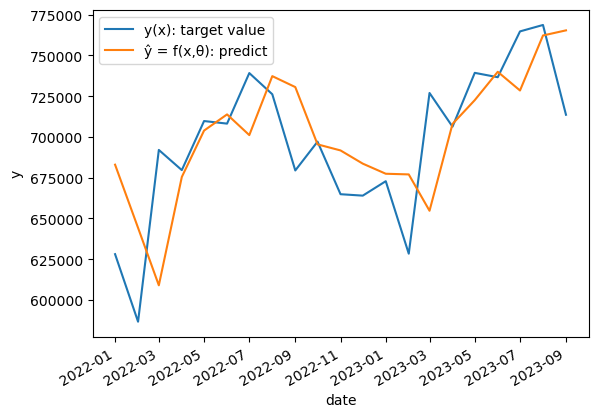

In [16]:
fig, ax = plt.subplots()
sns.lineplot(x=df_result['date'], y=df_result['y'], label='y(x): target value')
sns.lineplot(x=df_result['date'], y=df_result['ŷ = f(x,θ)'], label='ŷ = f(x,θ): predict')
fig.autofmt_xdate()

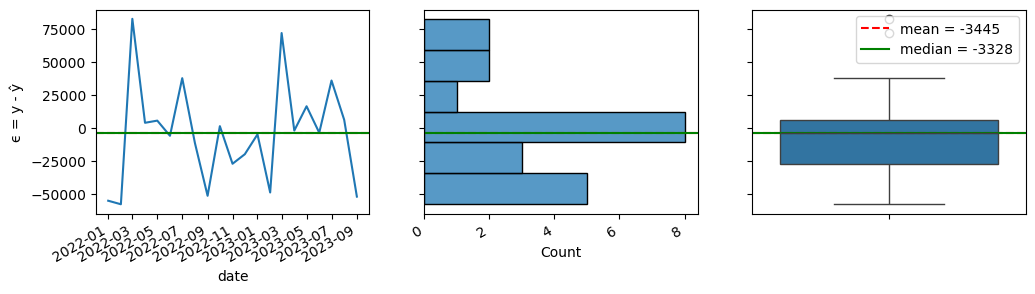

In [17]:
fig, (ax_plot, ax_hist, ax_box) = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 3))

mean = df_result['ϵ = y - ŷ'].mean()
median = df_result['ϵ = y - ŷ'].median()

sns.lineplot(x = df_result['date'], y = df_result['ϵ = y - ŷ'], ax=ax_plot)
ax_plot.axhline(mean, color='r', linestyle='--')
ax_plot.axhline(median, color='g', linestyle='-')

sns.histplot(y = df_result['ϵ = y - ŷ'], ax=ax_hist)
ax_hist.axhline(mean, color='r', linestyle='--', label='mean')
ax_hist.axhline(median, color='g', linestyle='-', label='median')

sns.boxplot(df_result['ϵ = y - ŷ'], ax=ax_box)
ax_box.axhline(mean, color='r', linestyle='--', label=f'mean = {mean:.0f}')
ax_box.axhline(median, color='g', linestyle='-', label=f'median = {median:.0f}')

fig.autofmt_xdate()
plt.legend(loc='upper right')

A norma do vetor de pesos é |w| = 0.7987


<Axes: xlabel='symbol_index', ylabel='weights'>

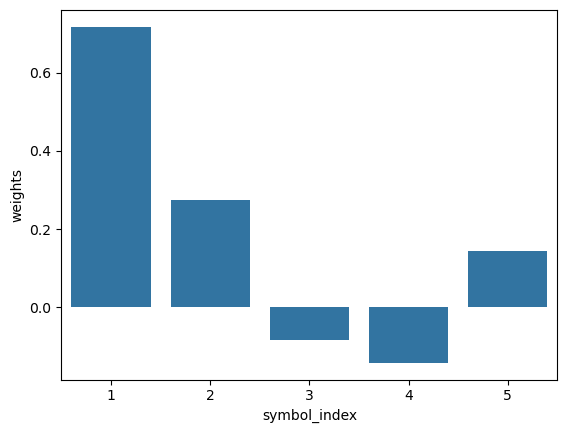

In [18]:
weights = model.coef_
norm_squared = weights @ weights
norm = norm_squared**(1/2)

print(f"A norma do vetor de pesos é |w| = {norm:.4f}")

df_weights = pd.DataFrame(weights, columns=['weights'])
df_weights['symbol_index'] = df_weights.index + 1

sns.barplot(x=df_weights['symbol_index'], y=df_weights['weights'])